In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

**Problem 1**: For a Gaussian distribution with distribution function
$$
p(x;\mu,\sigma) = \frac{1}{\sigma \sqrt{2\pi}}e^{-(x-\mu)^{2}/2\sigma^{2}},
$$
show that
$$
\mathbb{V}(X) = \sigma^{2}.
$$

Proof:

We know that the mean of this Gaussian distribution is $\mathbb{E}[X] = \mu$. Therefore,

$$
\operatorname{Var}(X) = \mathbb{E}\left[(X-\mathbb{E}[X])^2\right]
= \mathbb{E}\left[(X-\mu)^2\right].
$$

Using the definition of expected value,

$$
\begin{aligned}
\operatorname{Var}(X)
&= \int_{-\infty}^{\infty} (x-\mu)^2 p(x;\mu,\sigma)\,dx \\
&= \int_{-\infty}^{\infty} (x-\mu)^2
\left(\frac{1}{\sigma\sqrt{2\pi}}e^{-(x-\mu)^2/(2\sigma^2)}\right)\,dx.
\end{aligned}
$$

Substitute
$$
\tilde{x} = \frac{x-\mu}{\sqrt{2}\sigma},
\qquad
x-\mu = \sqrt{2}\sigma\tilde{x},
\qquad
 dx = \sqrt{2}\sigma\,d\tilde{x}.
$$
Then

$$
\operatorname{Var}(X)
= \frac{2\sigma^2}{\sqrt{\pi}}
\int_{-\infty}^{\infty} \tilde{x}^2e^{-\tilde{x}^2}\,d\tilde{x}.
$$

Using integration by parts, let
$$
u = \tilde{x},
\qquad
 dv = \tilde{x}e^{-\tilde{x}^2}\,d\tilde{x}.
$$
Then
$$
du = d\tilde{x},
\qquad
 v = -\frac{1}{2}e^{-\tilde{x}^2}.
$$
Therefore,

$$
\begin{aligned}
\int_{-\infty}^{\infty} \tilde{x}^2e^{-\tilde{x}^2}\,d\tilde{x}
&= \left[-\frac{1}{2}\tilde{x}e^{-\tilde{x}^2}\right]_{-\infty}^{\infty}
+ \frac{1}{2}\int_{-\infty}^{\infty}e^{-\tilde{x}^2}\,d\tilde{x} \\
&= 0 + \frac{1}{2}\sqrt{\pi}
= \frac{\sqrt{\pi}}{2}.
\end{aligned}
$$

Finally,
$$
\operatorname{Var}(X)
= \frac{2\sigma^2}{\sqrt{\pi}}\cdot\frac{\sqrt{\pi}}{2}
= \sigma^2.
$$
Thus, $\mathbb{V}(X) = \sigma^2$.

**Problem 2**: I hate teaching determinants, but I need to have y'all think about them for a minute.  So, for $n\times n$ matrix ${\bf A}$, we define the determinant, say $\text{det}({\bf A})$ to be 
$$
\text{det}({\bf A}) = \sum_{j=1}^{n}(-1)^{j-1}a_{1j}\text{det}({\bf M}_{1j}),
$$
where ${\bf M}_{1j}$ is the *minor* matrix formed by deleting the row and column which $a_{1j}$ is in.  Thus for a $3\times 3$, we get 
$$
\text{det} \begin{pmatrix}a_{11} & a_{12} & a_{13}\\ a_{21} & a_{22} & a_{23}\\ a_{31} & a_{32} & a_{33}\end{pmatrix}
= a_{11}~\text{det}\begin{pmatrix}a_{22} & a_{23}\\ a_{32} & a_{33}\end{pmatrix}
 - a_{12}~\text{det}\begin{pmatrix}a_{21} & a_{23}\\ a_{31} & a_{33}\end{pmatrix}
 + a_{13}~\text{det}\begin{pmatrix}a_{21} & a_{22}\\ a_{31} & a_{32}\end{pmatrix}

$$



There are more general definitions, but this will suffice for now.  Anyway, prove that the for a diagonal matrix, say ${\bf D}$ with diagonal entries $d_{jj}$ that 
$$
\text{det}({\bf D}) = \prod_{j=1}^{n}d_{jj}.  
$$

### Answer

Using the definition of the determinant as provided above, we can write $\det(D)$ as:

$$
\det(D) = \sum_{j=1}^{n}(-1)^{j-1}d_{1j}\det({\bf D}_{1j})
$$

Since $D$ is diagonal, $d_{1j}=0$ for every $j>1$. Therefore, only the $j=1$ term remains:

$$
\det(D) = (-1)^{1-1}d_{11}\det({\bf D}_{11})
= d_{11}\det({\bf D}_{11}).
$$

Here, ${\bf D}_{11}$ denotes the minor obtained by deleting the first row and first column of $D$. It is also diagonal, with diagonal entries $d_{22},d_{33},\ldots,d_{nn}$. Expanding its determinant along its first row gives

$$
\det({\bf D}_{11}) = d_{22}\det({\bf D}_{22}),
$$

where ${\bf D}_{22}$ denotes the minor of the original matrix obtained after deleting the first two rows and first two columns. Continuing this process,

$$
\begin{aligned}
\det(D)
&= d_{11}\det({\bf D}_{11}) \\
&= d_{11}d_{22}\det({\bf D}_{22}) \\
&= d_{11}d_{22}d_{33}\det({\bf D}_{33}) \\
&\quad\vdots \\
&= d_{11}d_{22}\cdots d_{nn}\det({\bf D}_{nn}).
\end{aligned}
$$

After deleting the first $n$ rows and columns, ${\bf D}_{nn}$ is the $0\times0$ matrix, whose determinant is $1$. Thus,

$$
\det(D) = d_{11}d_{22}\cdots d_{nn}
= \prod_{j=1}^{n}d_{jj}.
$$

**Problem 3**: For the two-dimensional Gaussian 
$$
p({\bf x},\boldsymbol{\mu},{\bf C}) = \frac{1}{\pi \text{det}(\boldsymbol{\Sigma})}e^{-\left<({\bf x}-\boldsymbol{\mu}),{\bf C}^{-1}({\bf x}-\boldsymbol{\mu})\right>}, ~ {\bf C} = {\bf U}\boldsymbol{\Sigma}^{2}{\bf U}^{T}, 
$$
choose two different pairs of mean and covariance matrices, i.e., select $(\boldsymbol{\mu}_{1},{\bf C}_{1})$ and $(\boldsymbol{\mu}_{2},{\bf C}_{2})$, plot the results, and explain the differences in your results.  

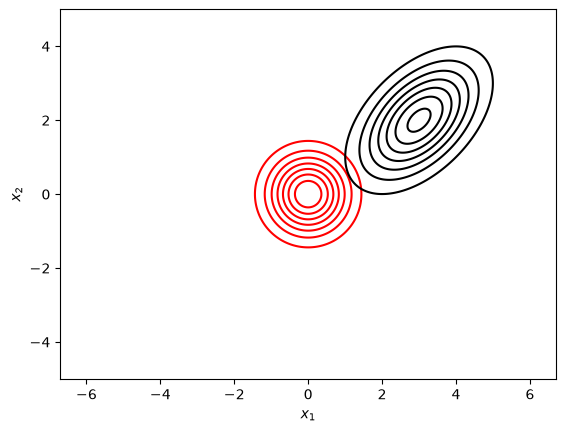

In [2]:
# define pdf
pgauss2d = lambda x, mu, C: (
    1 / (np.pi * np.sqrt(np.linalg.det(C)))
    * np.exp(-np.einsum('...i,ij,...j->...', x - mu, np.linalg.inv(C), x - mu))
)

mu1 = np.array([0, 0])
C1 = np.array([[1, 0], [0, 1]])

mu2 = np.array([3, 2])
C2 = np.array([[2, 1], [1, 2]])

xvals = np.linspace(-5, 5, 500)
yvals = np.linspace(-5, 5, 500)

X, Y = np.meshgrid(xvals, yvals)
positions = np.dstack((X, Y))

pdf1 = pgauss2d(positions, mu1, C1)
pdf2 = pgauss2d(positions, mu2, C2)

plt.contour(X, Y, pdf1, colors='r')
plt.contour(X, Y, pdf2, colors='k')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.axis('equal')
plt.show()


**Problem 4** (Grad/Extra Credit): For the two dimensional Gaussian defined by average $\boldsymbol{\mu}$ and covariance matrix ${\bf C}$ as above, find the conditional distribution 
$$
p(x_{1}|x_{2}=x_{\ast}) = p(x_{1},x_{2}=x_{\ast})/p(x_{2}=x_{\ast})
$$

Not attempted yet, but will try:)